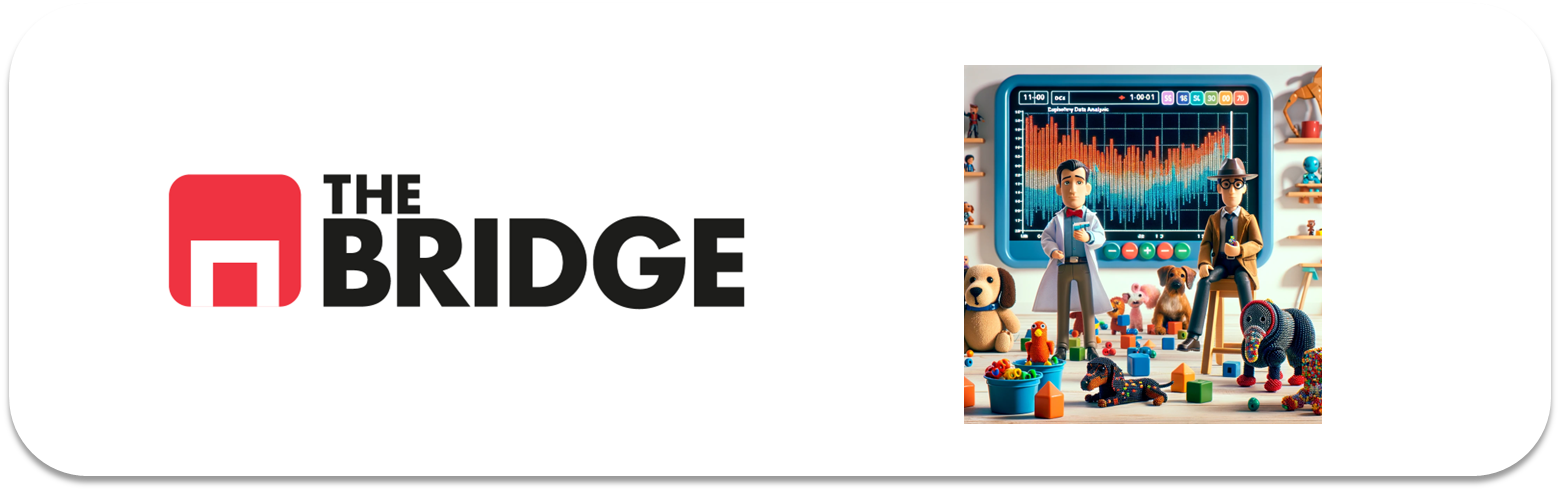

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import seaborn as sns
import bootcampviztools
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df = pd.read_csv("./data/titanic.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [4]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [6]:
df.drop(columns=["deck", "survived", "pclass","embarked"], inplace=True)

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [7]:
df["family_members"] = df.parch + df.sibsp
df.drop(columns=["parch", "sibsp"], inplace=True)

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [8]:
df.loc[df["embark_town"].isna(),"embark_town"] = df["embark_town"].mode()

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [9]:
mediana_woman = df.loc[df.who == "woman", "age"].mean()
mediana_man = df.loc[df.who == "man", "age"].mean()
mediana_child = df.loc[df.who == "child", "age"].mean()

df.loc[(df.who == "woman") & (df.age.isna()), "age"] = mediana_woman
df.loc[(df.who == "man") & (df.age.isna()), "age"] = mediana_man
df.loc[(df.who == "child") & (df.age.isna()), "age"] = mediana_child


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

Distribución Categóricas:


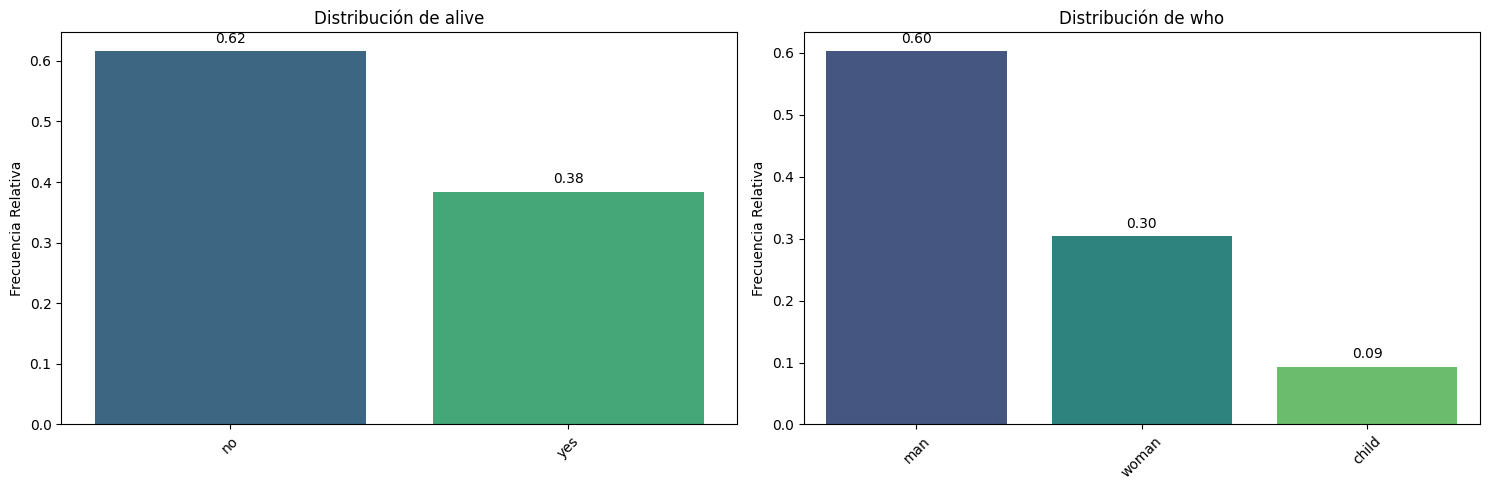

Bivariante Categóricas:


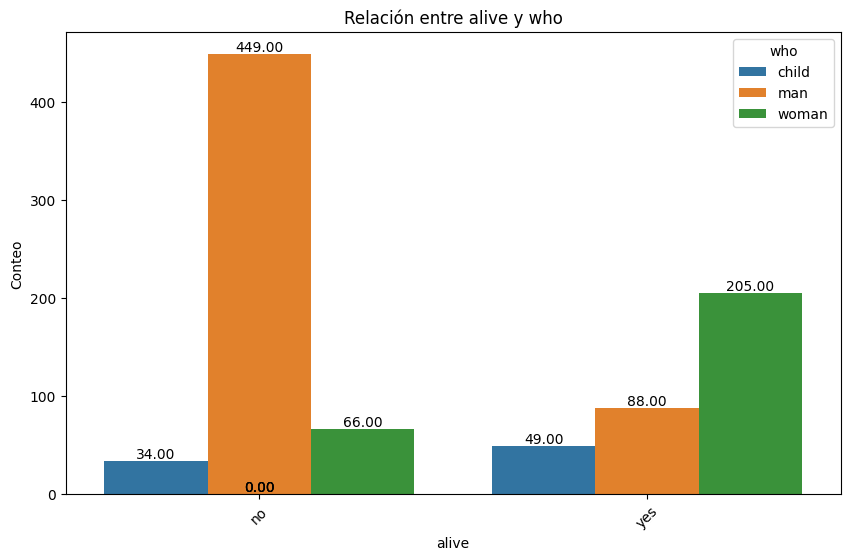

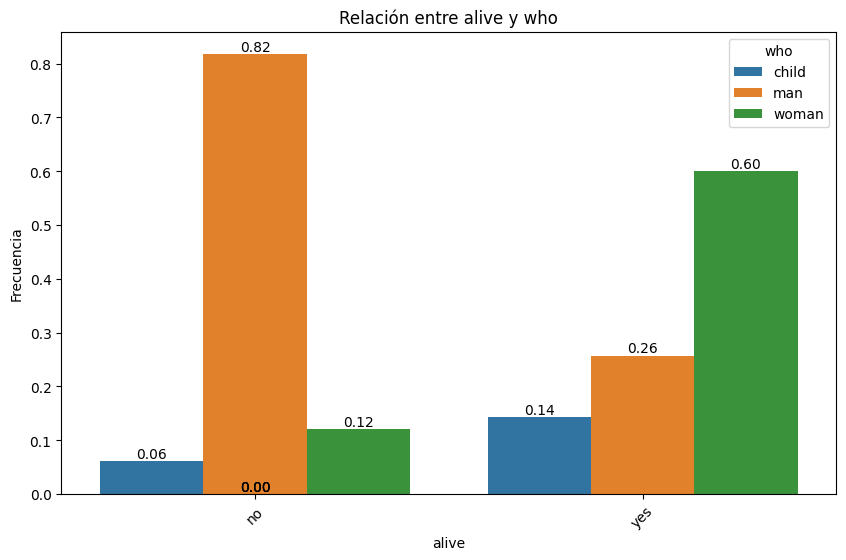

Tabla de contingencia 
 who    child  man  woman
alive                   
no        34  449     66
yes       49   88    205


Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


In [10]:
print("Distribución Categóricas:")
bootcampviztools.pinta_distribucion_categoricas(df,["alive","who"], relativa= True, mostrar_valores= True)
print("Bivariante Categóricas:")
bootcampviztools.plot_categorical_relationship_fin(df, "alive","who", show_values= True)
bootcampviztools.plot_categorical_relationship_fin(df, "alive","who", show_values= True, relative_freq=True)
tabla_contingencia = pd.crosstab(df['alive'], df['who'])
print(f"Tabla de contingencia \n {tabla_contingencia}{"\n"*2}")
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)


2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

Distribución Categóricas:


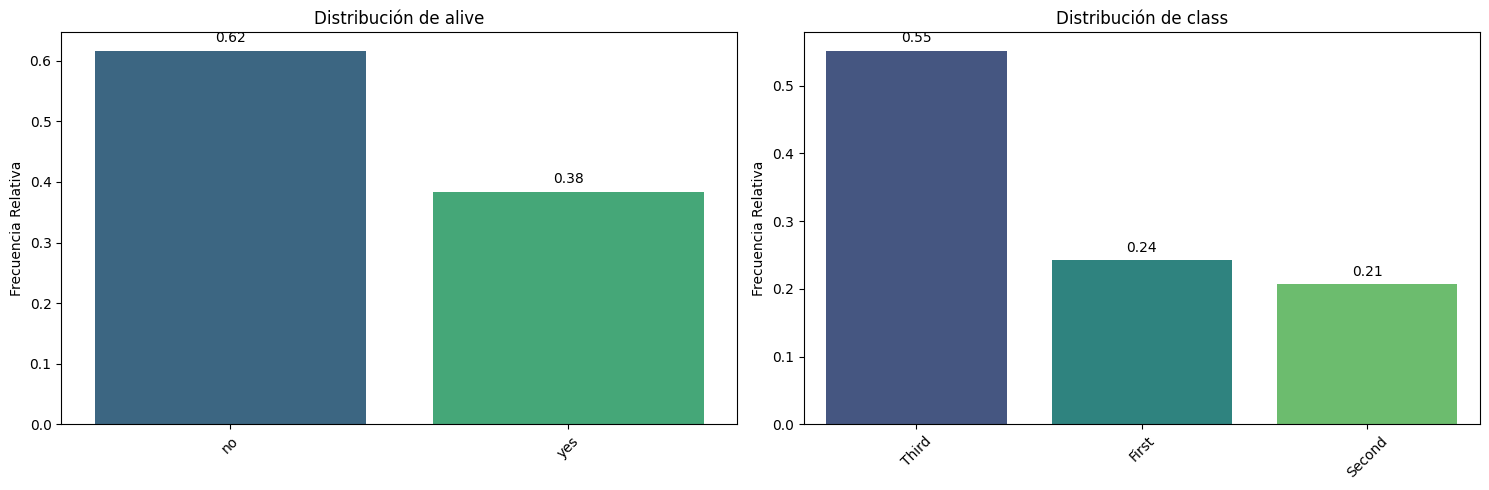

Bivariante Categóricas:


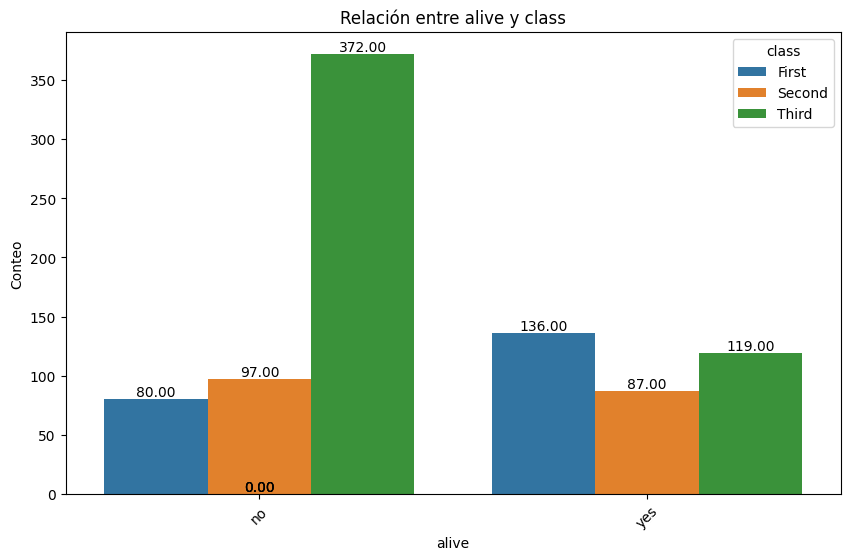

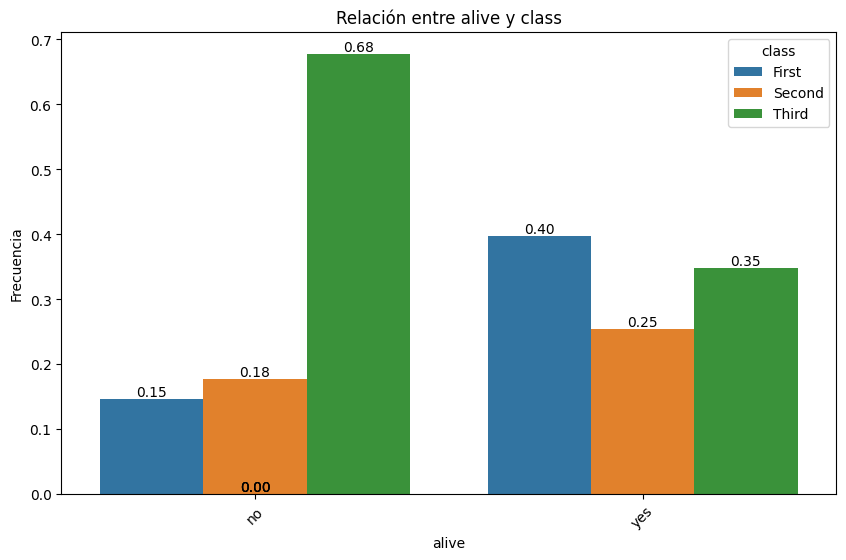

Tabla de contingencia 
 class  First  Second  Third
alive                      
no        80      97    372
yes      136      87    119


Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


In [11]:
print("Distribución Categóricas:")
bootcampviztools.pinta_distribucion_categoricas(df,["alive","class"], relativa= True, mostrar_valores= True)
print("Bivariante Categóricas:")
bootcampviztools.plot_categorical_relationship_fin(df, "alive","class", show_values= True)
bootcampviztools.plot_categorical_relationship_fin(df, "alive","class", show_values= True, relative_freq=True)
tabla_contingencia = pd.crosstab(df['alive'], df['class'])
print(f"Tabla de contingencia \n {tabla_contingencia}{"\n"*2}")
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)


3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

Distribución Categóricas:


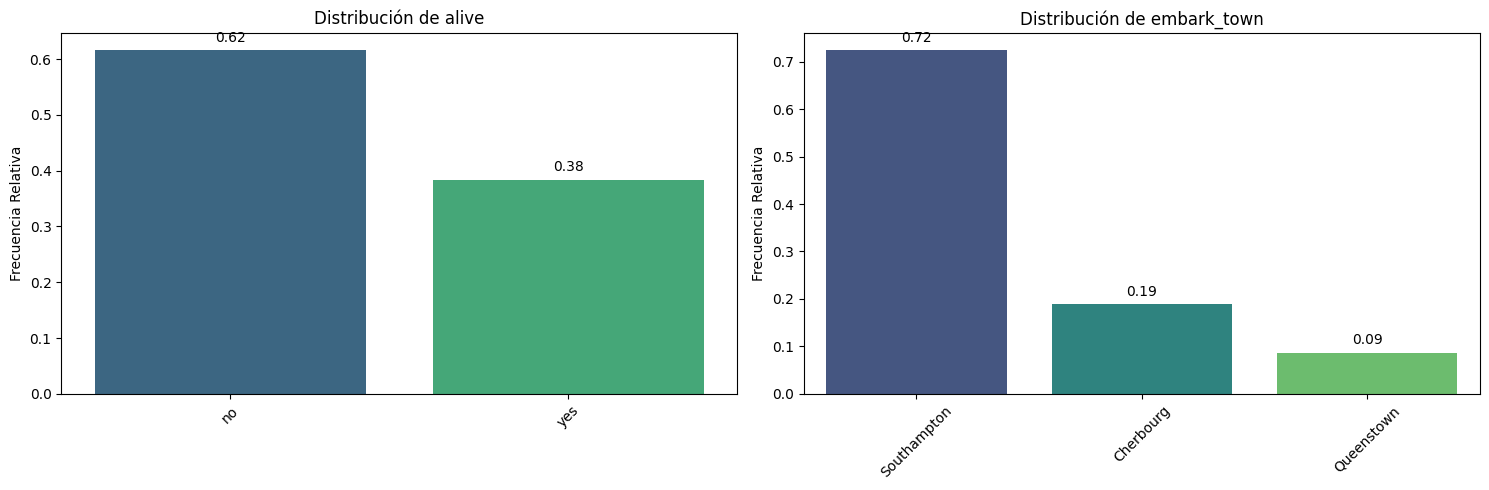

Bivariante Categóricas:


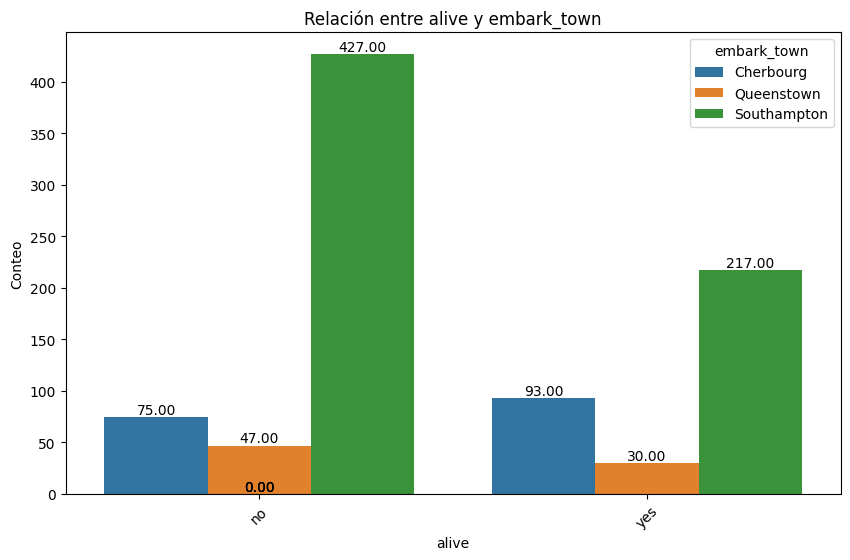

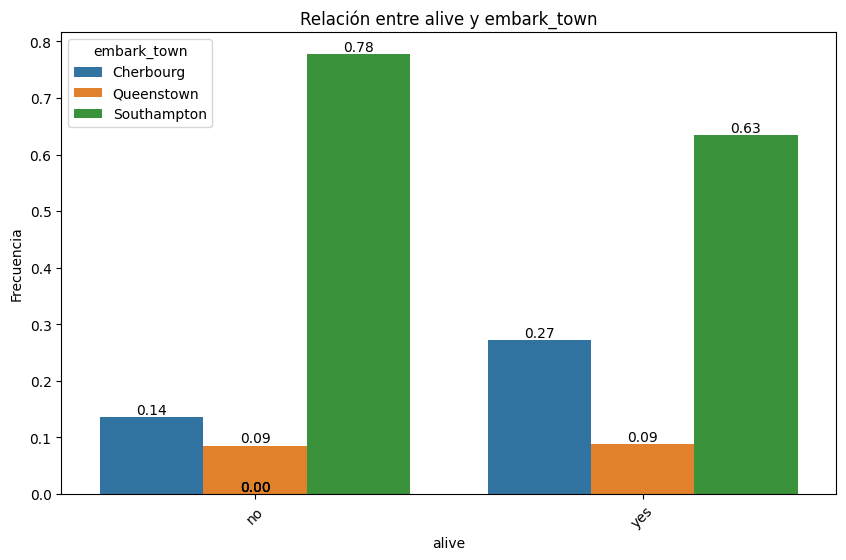

Tabla de contingencia 
 embark_town  Cherbourg  Queenstown  Southampton
alive                                          
no                  75          47          427
yes                 93          30          217


Valor Chi-Cuadrado: 26.48914983923762
P-Value: 1.769922284120912e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.7480315  47.5511811 397.7007874]
 [ 64.2519685  29.4488189 246.2992126]]


In [12]:
print("Distribución Categóricas:")
bootcampviztools.pinta_distribucion_categoricas(df,["alive","embark_town"], relativa= True, mostrar_valores= True)
print("Bivariante Categóricas:")
bootcampviztools.plot_categorical_relationship_fin(df, "alive","embark_town", show_values= True)
bootcampviztools.plot_categorical_relationship_fin(df, "alive","embark_town", show_values= True, relative_freq=True)
tabla_contingencia = pd.crosstab(df['alive'], df['embark_town'])
print(f"Tabla de contingencia \n {tabla_contingencia}{"\n"*2}")
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)


4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

In [13]:
tabla_contingencia = pd.crosstab(df['alive'], df['fare'])
print(f"Tabla de contingencia \n {tabla_contingencia}{"\n"*2}")
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Tabla de contingencia 
 fare   0.0000    4.0125    5.0000    6.2375    6.4375    6.4500    6.4958    \
alive                                                                         
no           14         1         1         1         1         1         2   
yes           1         0         0         0         0         0         0   

fare   6.7500    6.8583    6.9500    ...  153.4625  164.8667  211.3375  \
alive                                ...                                 
no            2         1         1  ...         1         0         0   
yes           0         0         0  ...         2         2         3   

fare   211.5000  221.7792  227.5250  247.5208  262.3750  263.0000  512.3292  
alive                                                                        
no            1         1         1         1         0         2         0  
yes           0         0         3         1         2         2         3  

[2 rows x 248 columns]


Valor Chi-Cuadrado: 425.

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?


In [14]:
df[df["fare"] == 0.0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0
413,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
466,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
481,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
597,male,49.000000,0.0,Third,man,True,Southampton,no,True,0
633,male,33.173123,0.0,First,man,True,Southampton,no,True,0


Respuesta: Posiblemente no los identificaron o podrían haberse colado en Southampton.

In [15]:
df.loc[df["age"].max()]

sex                      male
age                      22.0
fare                      9.0
class                   Third
who                       man
adult_male               True
embark_town       Southampton
alive                      no
alone                    True
family_members              0
Name: 80, dtype: object

La persona con más edad falleció.

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

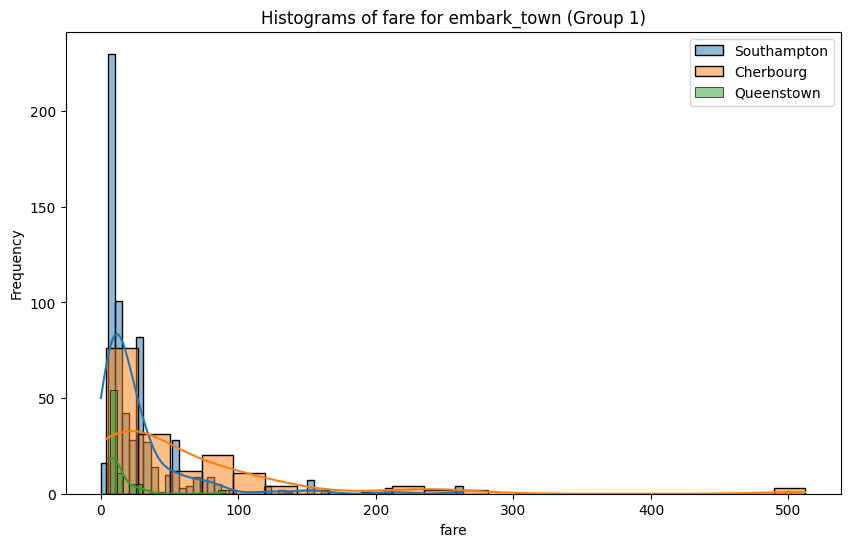

c:\Users\dgord\Documents\GitHub\DS-Online-Dani-Garcia-Ordiales\03_Data_Analysis\Sprint_07\Unidad_02_Estadistica_Descriptiva_Multivariante\03_Practica_Obligatoria\bootcampviztools.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


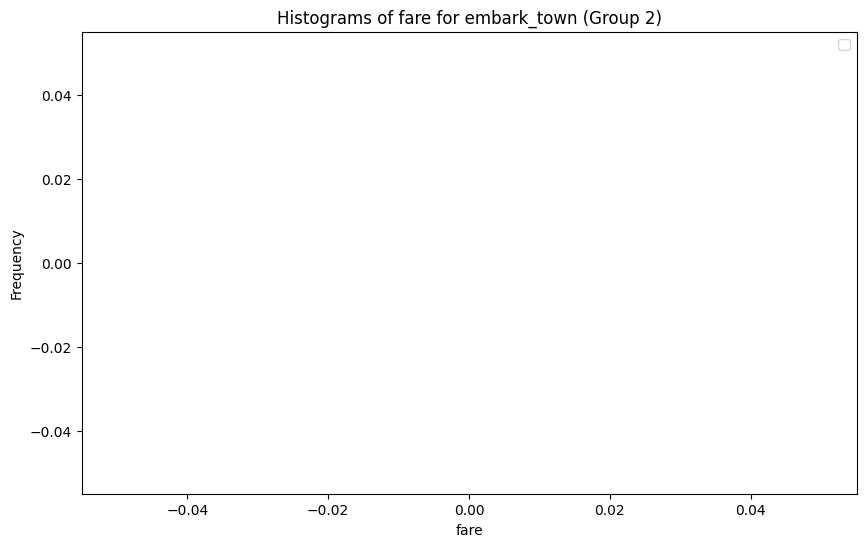

In [16]:
bootcampviztools.plot_grouped_histograms(df, cat_col="embark_town",num_col="fare", group_size=3)

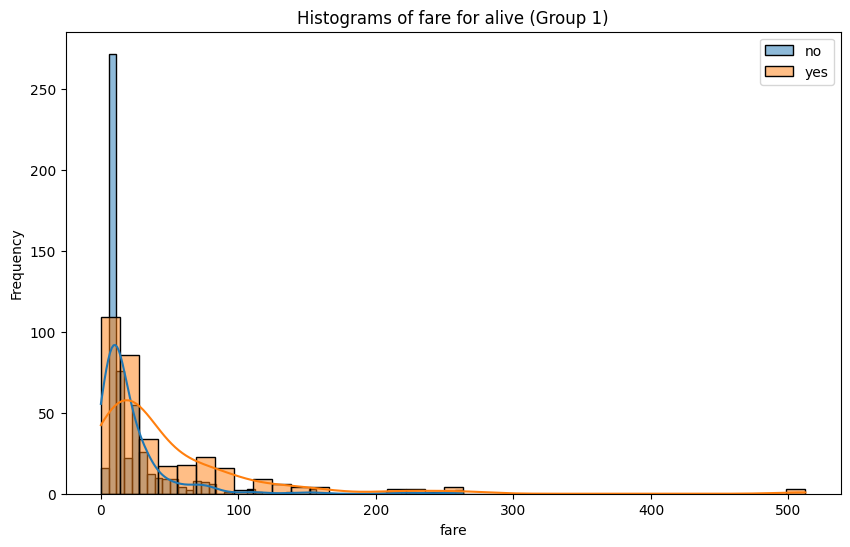

In [17]:
bootcampviztools.plot_grouped_histograms(df, cat_col="alive",num_col="fare", group_size=2)

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

Sobrevive no:


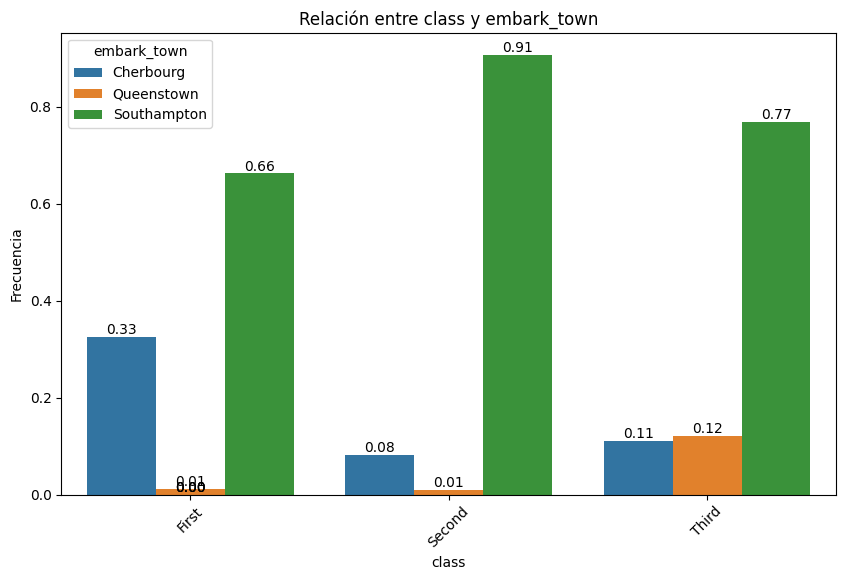

Sobrevive yes:


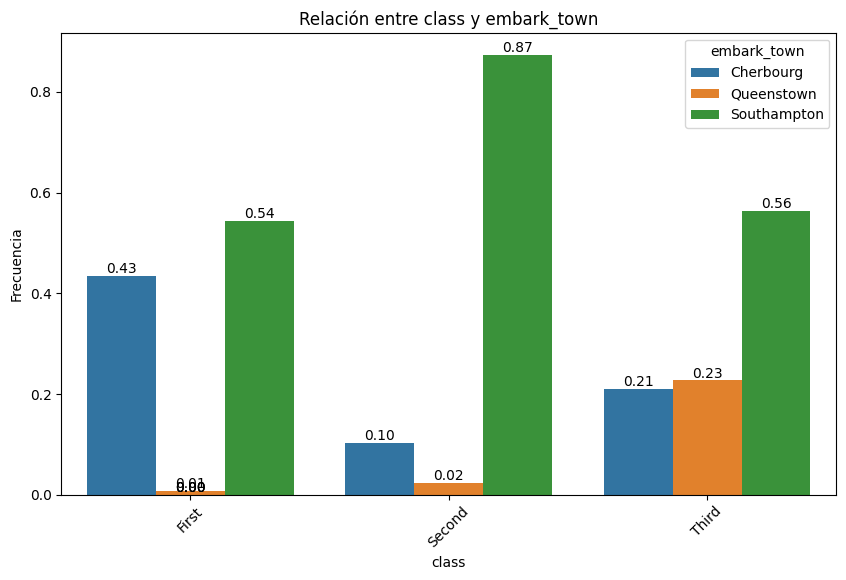

In [18]:
columnas = ["alive", "embark_town", "class"] 
col_directora = "alive"
col_1 = [col for col in columnas if col != col_directora][0]
col_2 = [col for col in columnas if col != col_directora][1]
diccionario_multivariante = {}
for valor in df[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor, [col_2, col_1]]


for valor,df in diccionario_multivariante.items():
    print(f"Sobrevive {valor}:")
    bootcampviztools.plot_categorical_relationship_fin(df,col_2,col_1, relative_freq= True, show_values= True)

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [19]:
grupos = df["alive"].unique()
supervivencia_por_billete = [df[df["alive"] == grupo]["fare"] for grupo in grupos] 
supervivencia_por_billete

KeyError: 'alive'

In [ ]:
f_val, p_val = stats.f_oneway(*supervivencia_por_billete) 
                                                    
print("Valor F:", f_val)
print("Valor p:", p_val)

NameError: name 'supervivencia_por_billete' is not defined

: 

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?